# Model Predictive Control for DED using GAMMA, Pytorch Implementation
created on 1/6/2025


In [13]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


In [14]:


import torch
import pickle

# Load model
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    nominal_params = pickle.load(file)

nominal_TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in nominal_TiDE.parameters())

P = 50
window = 50




In [15]:
total_params = sum(p.numel() for p in nominal_TiDE.parameters())
print(f'Total number of parameters: {total_params}')

Total number of parameters: 796594


In [16]:
# Import all the packages we need
import numpy as np
import cupy as cp
cp.cuda.Device(3).use()
import pandas as pd
from typing import Optional, Tuple
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm

# from pytorch_forecasting.metrics.quantile import QuantileLoss

# from scipy.optimize import minimize, Bounds

# For TiDE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

from sklearn.preprocessing import StandardScaler
from torch.nn import functional as F

import os
import shutil
import warnings
import pickle

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

# import functions
from TiDE import TideModule, quantile_loss, TiDE_forward

from RobustMPC_pytorch import RMPC
from nn_functions import surrogate
from torchmin import minimize as pytorch_minimize
from scipy.optimize import minimize, Bounds

from moving_average import moving_average_1d
import copy

from GAMMA_obj_temp_depth import GAMMA_obj
from obj_fun_depth import RMPC_obj_wo_constraint, RMPC_obj_wo_constraint_scipy
from GAMMA_MPC_temp_depth import GAMMA_MPC
from utils import sigmoid, LossParameters, GlobalState


cuda is available


### Load pre-trained model

In [17]:
####################### SEUL LEE #######################

import torch
import pickle

# Load model
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    params = pickle.load(file)

model = params['model'].to('cpu')
print(model)

# Extract dimensions
P = 50  # output_chunk_length
input_chunk_length = model.input_chunk_length
output_chunk_length = model.output_chunk_length
input_dim = model.input_dim
output_dim = model.output_dim
past_cov_dim = model.past_cov_dim
future_cov_dim = model.future_cov_dim
static_cov_dim = model.static_cov_dim
nr_params = model.nr_params

print("input_chunk_length:", input_chunk_length)
print("output_chunk_length:", output_chunk_length)
print("input_dim:", input_dim)
print("output_dim:", output_dim)
print("past_cov_dim:", past_cov_dim)
print("future_cov_dim:", future_cov_dim)
print("static_cov_dim:", static_cov_dim)
print("nr_params:", nr_params)

# Generate dummy input
B = 1  # batch size
x_past = torch.randn(B, input_chunk_length, input_dim)
x_future_covariates = torch.randn(B, output_chunk_length, future_cov_dim) if future_cov_dim > 0 else None
x_static_covariates = torch.randn(B, static_cov_dim) if static_cov_dim > 0 else None

# Run model
x_in = (x_past, x_future_covariates, x_static_covariates)
y = model(x_in)

print("Input shape:")
print("  x_past:", x_past.shape)
if x_future_covariates is not None:
    print("  x_future_covariates:", x_future_covariates.shape)
if x_static_covariates is not None:
    print("  x_static_covariates:", x_static_covariates.shape)

print("Output shape:", y.shape)  # (B, output_chunk_length, output_dim, nr_params)


TideModule(
  (future_cov_projection): ResidualBlock(
    (dense): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=4, bias=True)
      (3): Dropout(p=0.2, inplace=False)
    )
    (skip): Linear(in_features=4, out_features=4, bias=True)
    (layer_norm): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
  )
  (encoders): Sequential(
    (0): ResidualBlock(
      (dense): Sequential(
        (0): Linear(in_features=500, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): Dropout(p=0.2, inplace=False)
      )
      (skip): Linear(in_features=500, out_features=128, bias=True)
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (decoders): Sequential(
    (0): ResidualBlock(
      (dense): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): ReLU()
   

### Build class for ML surrogate

In [18]:
'''
inputs:
    nominal_param: nominal parameters saved from nominal_preparation
    nominal_NN   : a complete nn.module model with the pretrained parameters are loaded
'''
TiDE = surrogate(nominal_params, nominal_TiDE)

### Load reference trajectory

#### Run GAMMA for initialization

In [19]:
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50 #50 

GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR, CLOUD_TARGET_BASE_PATH, solidus_temp, window, init_runs, sim_interval)
init_avg = GAMMA_class.run_initial_steps()
init_avg = torch.tensor(init_avg,dtype=torch.float32)[:,-window:] # shape = [2,50]

100%|██████████| 250/250 [00:06<00:00, 38.55it/s]


#### Fix covariates as the configuration is given

In [20]:
df_one_print = pd.read_csv('single_track_ref.csv')

loc_X_list = df_one_print["X"].to_numpy().reshape(-1,1)
loc_Y_list = df_one_print["Y"].to_numpy().reshape(-1,1)
loc_Z_list = df_one_print["Z"].to_numpy().reshape(-1,1)
dist_X_list = df_one_print["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y_list = df_one_print["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
scan_spd_list = df_one_print["scanning_speed"].to_numpy().reshape(-1,1)
# laser on/off indicator
laser_on_off = df_one_print["laser_power_number"].to_numpy().reshape(-1,1)
# laser power
laser_power_ref = torch.tensor(df_one_print["Laser_power"].to_numpy().reshape(-1,1),dtype=torch.float32)
laser_power_past = laser_power_ref[:window]

# fix_covariates = torch.tensor(np.concatenate((loc_X_list,loc_Y_list,loc_Z_list,dist_X_list,dist_Y_list,scan_spd_list, laser_on_off),axis=1),dtype=torch.float32)
fix_covariates = torch.tensor(np.concatenate((loc_Z_list,dist_X_list,dist_Y_list),axis=1),dtype=torch.float32)

# temporary ref
# apply moving average for mp temp
mp_temp_raw = df_one_print["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp

mp_temp_ref = torch.tensor(mp_temp,dtype=torch.float32)

# replace the reference with fixed temperature
#mp_temp_ref = torch.ones([6120],dtype=torch.float32)*3000


# # manually fix reference
# mp_temp_ref[50:65] = torch.tensor(mp_temp_raw[50:65],dtype=torch.float32)

# plt.plot(np.repeat(mp_temp_raw[0:50],5), label='raw data')
# plt.plot(np.repeat(mp_temp_ref[0:50],5), label='ref_smoothing')
# plt.plot(np.repeat(init_avg,5), label='GAMMA+avg')
# plt.plot(GAMMA_class.melt_pool_temp_save["temp"].values, label='GAMMA raw')
# plt.legend()


# replace the reference with fixed temperature
#mp_temp_ref = torch.ones([6196+50],dtype=torch.float32)*3500


In [21]:
test_tensor_1 = torch.tensor([1,2,3,4,5,6,7])
test_tensor_2 = torch.tensor([1,1,1,1,1,1,1])

indices_1 = torch.where((test_tensor_1 > 3) & (test_tensor_1 < 5))[0]

# Find indices in test_tensor_2 where elements are > 30 and < 40
indices_2 = torch.where((test_tensor_2 <2) )[0]

print("Indices in test_tensor_1:", indices_1)
print("Indices in test_tensor_2:", indices_2)

intersection = torch.tensor(np.intersect1d(indices_1, indices_2))

print("Intersection of indices_1 and indices_2:", intersection)
print(f"selected term in tensor_1 = {test_tensor_1[intersection]}")
print(f"selected term in tensor_2 = {test_tensor_2[intersection]}")

all_indices = torch.arange(test_tensor_1.size(0))
remaining_indices = all_indices[~torch.isin(all_indices,intersection)]

filtered_tensor = test_tensor_1[remaining_indices]

print(filtered_tensor)


Indices in test_tensor_1: tensor([3])
Indices in test_tensor_2: tensor([0, 1, 2, 3, 4, 5, 6])
Intersection of indices_1 and indices_2: tensor([3])
selected term in tensor_1 = tensor([4])
selected term in tensor_2 = tensor([1])
tensor([1, 2, 3, 5, 6, 7])


In [22]:
import torch
from torch.nn import ReLU
from utils import softmax_max, softmax_min

# LossParam = LossParameters(alpha0=1, delta_alpha = 5, lamda0 = 10) #This set works pretty well with torch.max, Q:R = 1:8

# LossParam = LossParameters(alpha0=1, delta_alpha = 2, lamda0 = 5) # This set works ok with sum(g2), Q:R = 1:8
# LossParam = LossParameters(alpha0=1, delta_alpha = 3, lamda0 = 10) for 0830_3 with Q:R = 1:8, torch.max, with K=-0.05, newton-exact

# LossParam = LossParameters(alpha0=1, delta_alpha = 3, lamda0 = 15)
LossParam = LossParameters(alpha0=1, delta_alpha = 3, lamda0 = 10)

relu = ReLU()
global_state = GlobalState()

def RMPC_obj_w_constraint(u_hat0:torch.tensor, # future u values within the control horizon, length = M; this should be the warm start version
                u_future_fix:torch.tensor, # future u values within the control horizon but not the design variables
                u_past:torch.tensor, # past u
                x_past_fix: torch.tensor, # past state of x, size (N,window)
                x_past:torch.tensor, # past state that changes
                SP_hat:torch.tensor, # Reference trajectory, length = P
                P, # Predictive Horizon
                NN_Nominal # NN object we're using
):
    ''' 
    All the data that goes into this module should be normalized
    '''    
    
    u_hat = u_hat0.reshape(-1,1)
    u_hat_in = u_hat0.unsqueeze(0)
    x_hat_all, x_hat_quantile = NN_Nominal.forward(u_hat, u_future_fix, u_past, x_past_fix, x_past)
    x_hat = x_hat_all[:,0]

    
    # compute objective value
    u_hat_temp = u_hat_in[0,:,0].reshape(-1,1) 

    #u = u_hat_temp[0].reshape(-1,1)
    u = u_past[-1].reshape(-1,1)
    u_hat1 = torch.concatenate((u,u_hat_temp)) # append the computed u with the history u 
    
    # get the elements that is at the corner
    # x at the corner
    #print("x_past_fix_shape : " , x_past_fix.shape)
    #print("x_past_fix[-1,0] : " , x_past_fix[-1,0])
    if x_past_fix[-1,0] >= -0.2:
    
        with torch.no_grad():
            # indices_1 = torch.where((u_future_fix[:,1] <= -0.95) | (u_future_fix[:,1] >= 0.95))[0]
            # indices_2 = torch.where((u_future_fix[:,2] <= -0.95) | (u_future_fix[:,2] >= 0.95))[0]
            indices_1 = torch.where((u_future_fix[:,1] <= -0.8))[0]
            indices_2 = torch.where((u_future_fix[:,2] <= -0.8))[0]
            intersection = torch.tensor(np.intersect1d(indices_1, indices_2))
            all_indices = torch.arange(u_future_fix[:,1].size(0))
            remaining_indices = all_indices[~torch.isin(all_indices,intersection)]
        
        
        # ======= using torch.min/torch.max ============
        #depth_max = torch.max(x_hat_all[:,1][remaining_indices])
        # depth_min = torch.min(x_hat_all[:,1][remaining_indices])
        
        # u_max = torch.max(u_hat0[remaining_indices])
        # u_min = torch.min(u_hat0[remaining_indices])
        
        # ======== using max ================
        # depth_max = torch.max(x_hat_all[:,1][remaining_indices].reshape(-1,1))
        # g2 = (depth_max - 0.412414)/0.412414
        # Loss_g2 = LossParam.lamda_1.item()*relu(g2) + 0.5*LossParam.alpha_1.item()*(relu(g2)**2)
        # Loss = Loss_g2 
        # LossParam.alpha_1 = np.min((LossParam.alpha_1*LossParam.delta_alpha,10000))
        # LossParam.lamda_1 = LossParam.lamda_1 + LossParam.alpha_1*relu(g2).item()
        
        # ======= look at all violation ====
        #depth = x_hat_all[:,1][remaining_indices].reshape(-1,1)
        depth_upper = x_hat_quantile[:,1,2][remaining_indices].reshape(-1,1)
        depth_lower = x_hat_quantile[:,1,0][remaining_indices].reshape(-1,1)
        
        #depth = x_hat_all[:,1].reshape(-1,1)
        g3 = (0.1354-depth_lower)/0.1354
        g2 = (depth_upper - 0.412414)/0.412414
        Loss_g2 = LossParam.lamda_1.item()*sum(relu(g2)) + 0.5*LossParam.alpha_1.item()*(sum(relu(g2))**2)
        LossParam.lamda_1 = LossParam.lamda_1 + LossParam.alpha_1*sum(relu(g2)).item()
        LossParam.alpha_1 = np.min((LossParam.alpha_1*LossParam.delta_alpha,10000))
        
        Loss_g3 = LossParam.lamda_2.item()*sum(relu(g3)) + 0.5*LossParam.alpha_2.item()*(sum(relu(g3))**2)
        LossParam.lamda_2 = LossParam.lamda_2 + LossParam.alpha_2*sum(relu(g3)).item()
        LossParam.alpha_2 = np.min((LossParam.alpha_2*LossParam.delta_alpha,10000))
        
        if torch.any(u_future_fix[0,0]!=u_future_fix[:,0]) or torch.any(u_future_fix[0,0] != x_past_fix[:,0]):
            Loss_g3 = 0     
    
        Loss = Loss_g2/30 + Loss_g3/30
        
        
        
    else: 
        Loss = 0
    
    Obj = 1 * torch.sum((x_hat-torch.tensor(SP_hat.transpose(1,0),dtype=torch.float32))**2) + 10*torch.sum((u_hat1[:-1]-u_hat_temp)**2) 
      
        
    # Normalize objective value
    if global_state.optim_iter_count == 0 or global_state.optim_iter_count == 300:
        global_state.update_f0(Obj.item())
    
    obj_s = Obj/global_state.get_f0()  


    # relu = ReLU()
    
    # penalty = torch.sum(relu(u - torch.ones_like(u))**2) + torch.sum(relu(-torch.ones_like(u) - u)**2)
    global_state.update_optim_iter_count()
    
    
    return obj_s + Loss/global_state.get_f0()


In [23]:
def plot_fig(MPC_GAMMA, N_step):
    plt.figure(figsize=[12,10])
    plt.subplot(3,1,1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step,0], label = "GAMMA simulation")
    plt.plot(MPC_GAMMA.NN_pred_save.detach().numpy()[:N_step,0], label="TiDE prediction")
    plt.plot(MPC_GAMMA.ref[:N_step], label="Reference")
    plt.legend()


    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Temperature (k)")

    plt.subplot(3,1,2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step,1], label = "GAMMA simulation")
    plt.plot(MPC_GAMMA.NN_pred_save.detach().numpy()[:N_step,1], label="TiDE prediction")
    plt.plot(np.linspace(0,N_step,N_step),0.225*np.ones(N_step))
    plt.plot(np.linspace(0,N_step,N_step),0.075*np.ones(N_step))
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    plt.subplot(3,1,3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step])
    plt.ylabel("Laser power (w)")
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.show()


  0%|          | 0/6196 [00:00<?, ?it/s]

[Step 50] Warm-start: 44 iterations


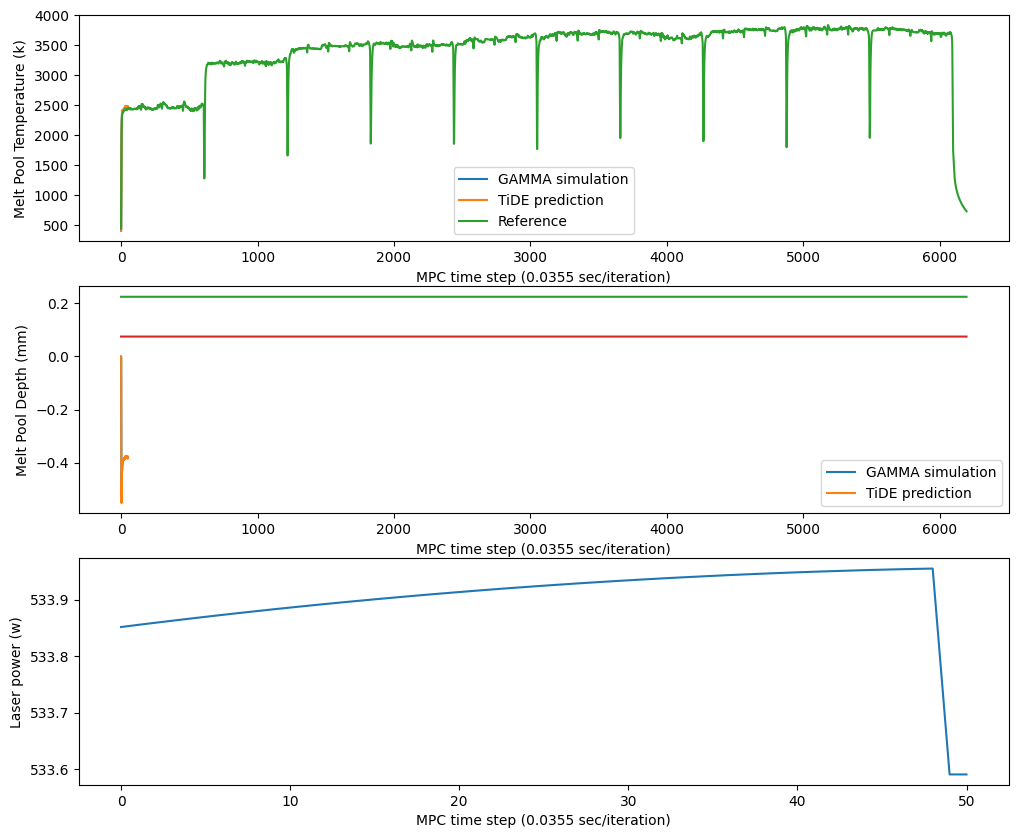

  0%|          | 2/6196 [00:01<49:59,  2.06it/s]  

[Step 51] Warm-start: 55 iterations


  0%|          | 3/6196 [00:01<44:56,  2.30it/s]

[Step 52] Warm-start: 60 iterations


  0%|          | 4/6196 [00:01<43:18,  2.38it/s]

...

[Step 647] Warm-start: 37 iterations


 10%|▉         | 599/6196 [04:07<35:17,  2.64it/s]

[Step 648] Warm-start: 33 iterations


 10%|▉         | 600/6196 [04:08<34:56,  2.67it/s]

[Step 649] Warm-start: 20 iterations
[Step 650] Warm-start: 30 iterations


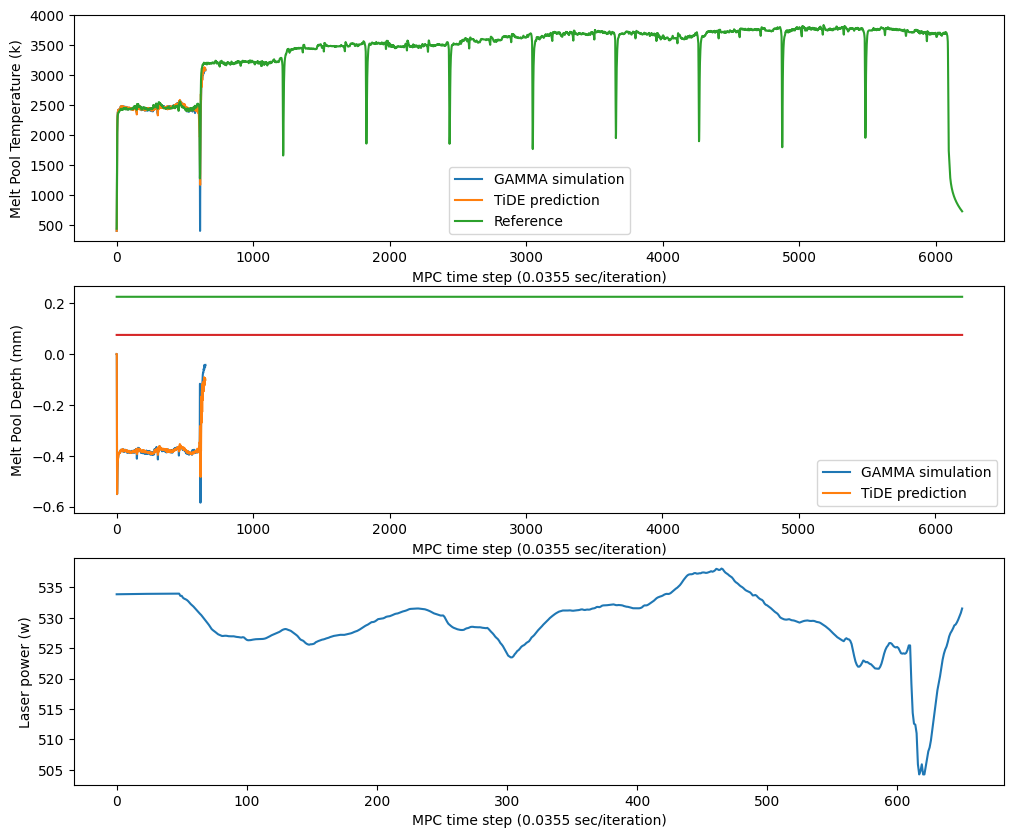

 10%|▉         | 602/6196 [04:09<44:52,  2.08it/s]

[Step 651] Warm-start: 36 iterations


 10%|▉         | 603/6196 [04:10<50:50,  1.83it/s]

[Step 652] Warm-start: 50 iterations


 10%|▉         | 604/6196 [04:10<45:50,  2.03it/s]

...

[Step 1247] Warm-start: 28 iterations


 19%|█▉        | 1199/6196 [09:06<38:06,  2.19it/s]

[Step 1248] Warm-start: 41 iterations


 19%|█▉        | 1200/6196 [09:06<35:49,  2.32it/s]

[Step 1249] Warm-start: 48 iterations
[Step 1250] Warm-start: 49 iterations


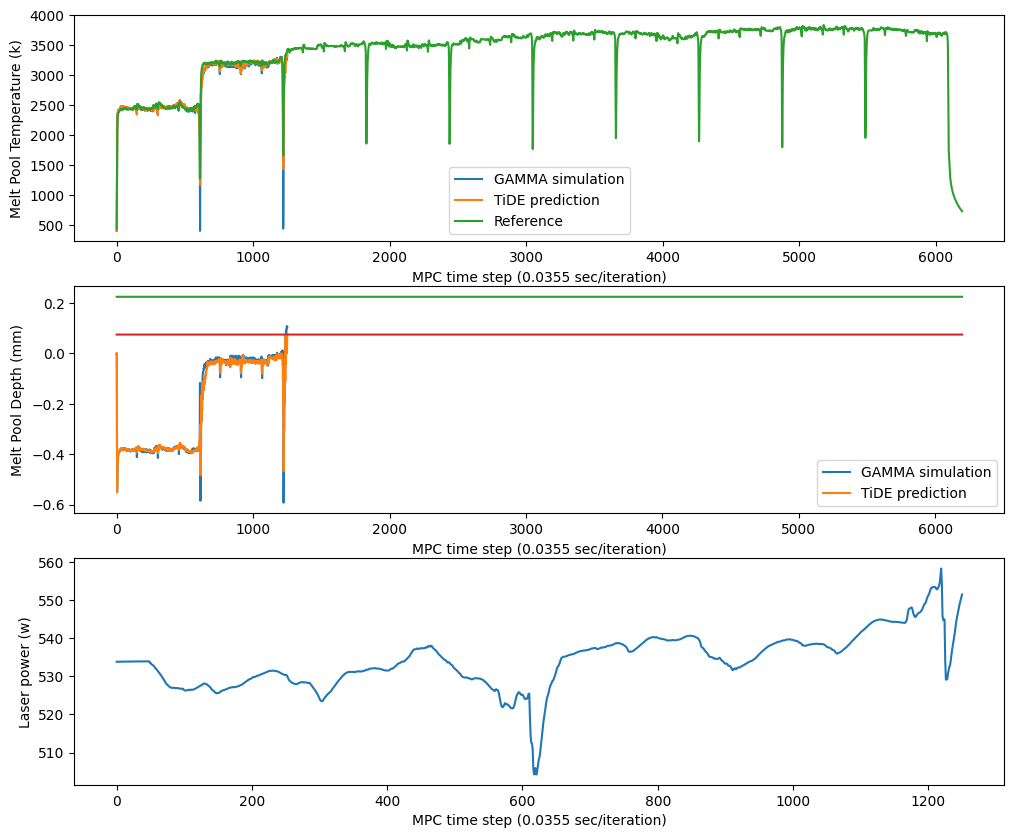

 19%|█▉        | 1202/6196 [09:08<40:23,  2.06it/s]

[Step 1251] Warm-start: 48 iterations


 19%|█▉        | 1203/6196 [09:08<38:11,  2.18it/s]

[Step 1252] Warm-start: 53 iterations


 19%|█▉        | 1204/6196 [09:08<38:02,  2.19it/s]

...

[Step 1847] Warm-start: 61 iterations


 29%|██▉       | 1799/6196 [14:04<50:48,  1.44it/s]

[Step 1848] Warm-start: 54 iterations


 29%|██▉       | 1800/6196 [14:04<47:22,  1.55it/s]

[Step 1849] Warm-start: 52 iterations
[Step 1850] Warm-start: 47 iterations


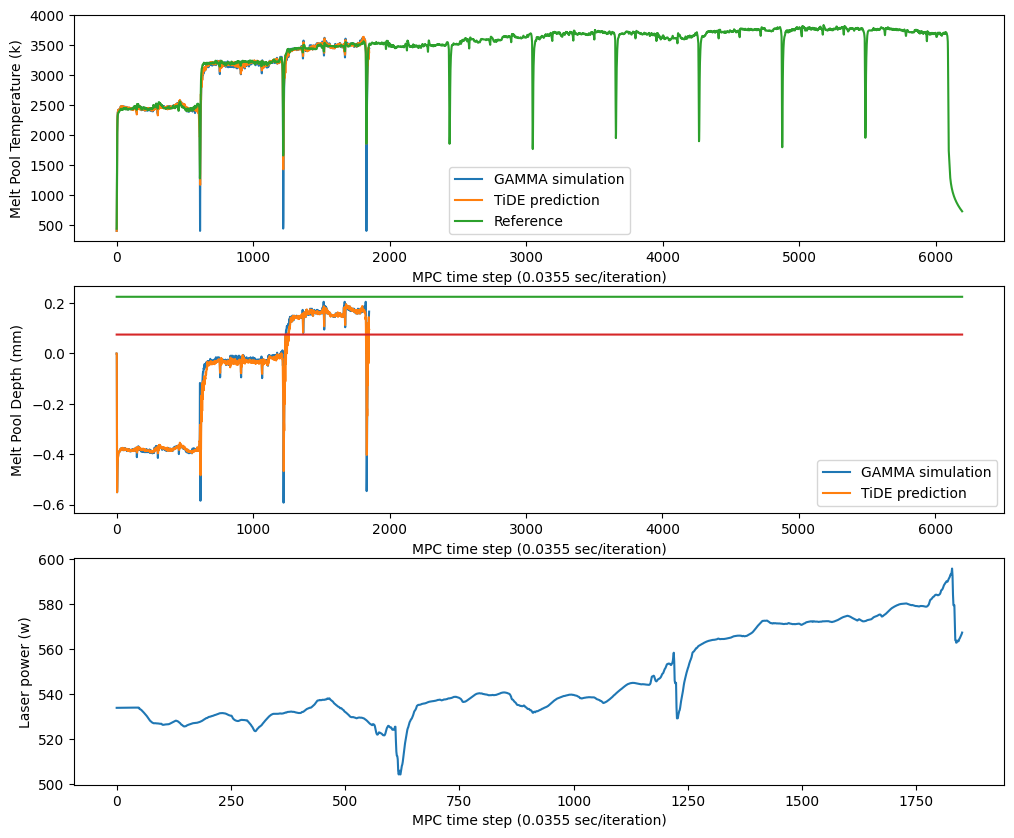

 29%|██▉       | 1802/6196 [14:05<44:15,  1.65it/s]

[Step 1851] Warm-start: 22 iterations


 29%|██▉       | 1803/6196 [14:06<45:27,  1.61it/s]

[Step 1852] Warm-start: 59 iterations


 29%|██▉       | 1804/6196 [14:07<56:30,  1.30it/s]

...

[Step 2447] Warm-start: 46 iterations


 39%|███▊      | 2398/6196 [1:00:22<11:46:08, 11.16s/it]

[Step 2448] Warm-start: 40 iterations


 39%|███▊      | 2400/6196 [1:00:37<9:46:34,  9.27s/it] 

[Step 2449] Warm-start: 39 iterations
[Step 2450] Warm-start: 21 iterations


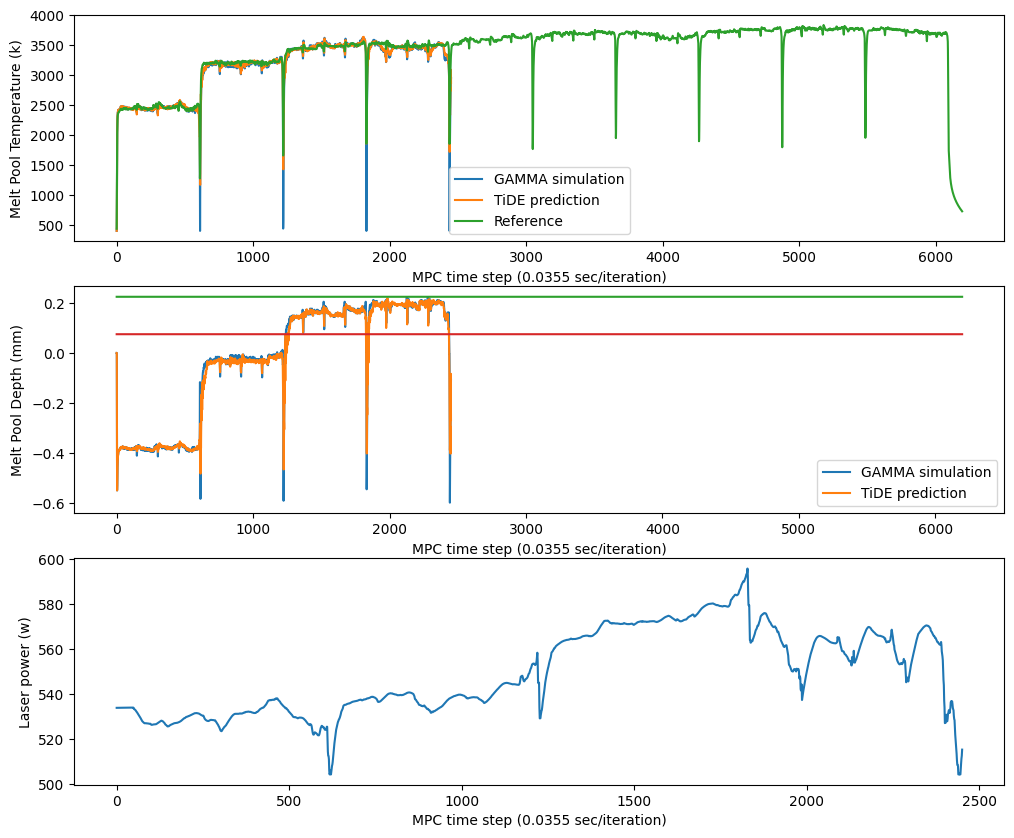

 39%|███▉      | 2401/6196 [1:00:43<8:42:50,  8.27s/it]

[Step 2451] Warm-start: 45 iterations


 39%|███▉      | 2402/6196 [1:00:55<9:44:00,  9.24s/it]

[Step 2452] Warm-start: 33 iterations


 39%|███▉      | 2403/6196 [1:01:02<9:06:01,  8.64s/it]

...

[Step 3048] Warm-start: 27 iterations


 48%|████▊     | 2999/6196 [1:46:29<8:10:45,  9.21s/it]

[Step 3049] Warm-start: 67 iterations


 48%|████▊     | 3000/6196 [1:46:46<10:03:06, 11.32s/it]

[Step 3050] Warm-start: 9 iterations


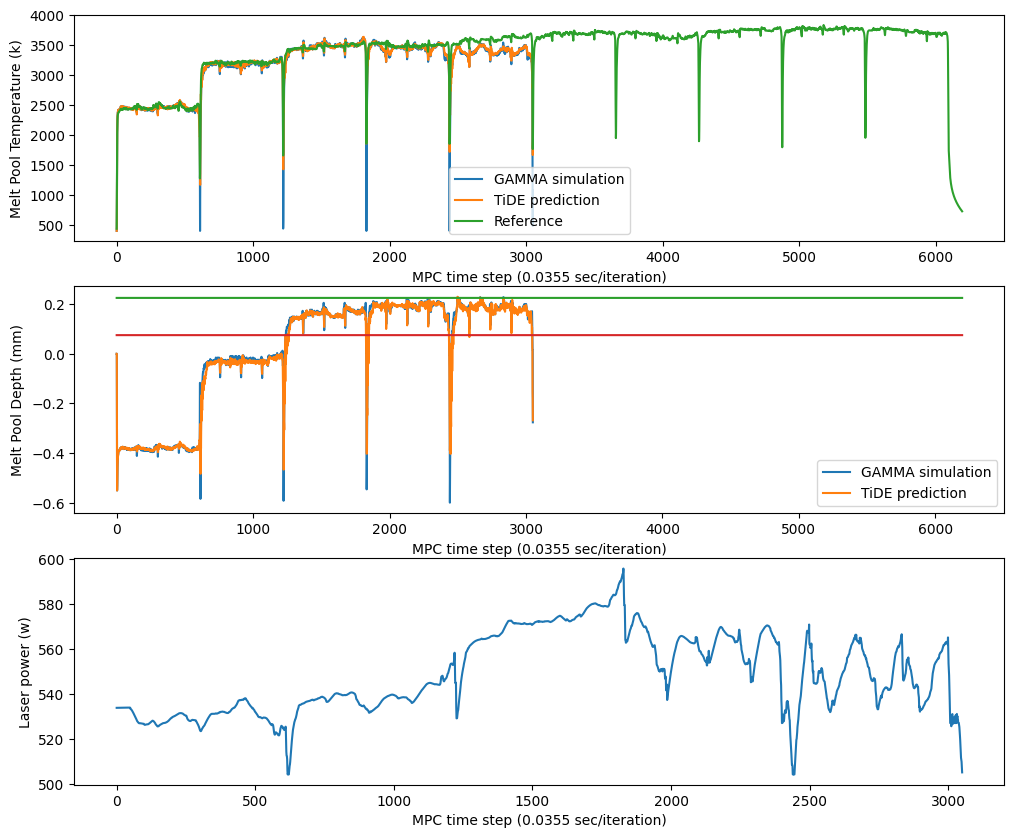

 48%|████▊     | 3001/6196 [1:46:52<8:38:20,  9.73s/it] 

[Step 3051] Warm-start: 55 iterations


 48%|████▊     | 3002/6196 [1:47:00<8:10:24,  9.21s/it]

[Step 3052] Warm-start: 40 iterations


 48%|████▊     | 3004/6196 [1:47:12<6:46:24,  7.64s/it]

...

[Step 3648] Warm-start: 2 iterations


 58%|█████▊    | 3599/6196 [2:30:09<1:42:11,  2.36s/it]

[Step 3649] Warm-start: 2 iterations


 58%|█████▊    | 3600/6196 [2:30:10<1:35:09,  2.20s/it]

[Step 3650] Warm-start: 4 iterations


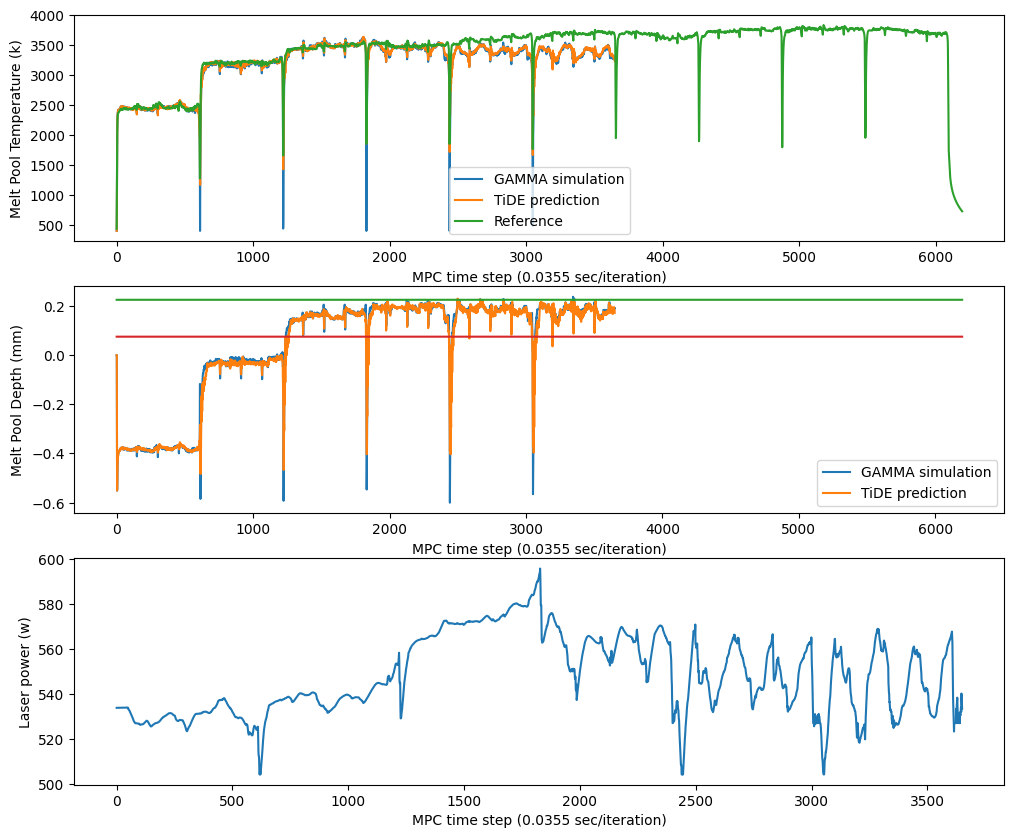

 58%|█████▊    | 3601/6196 [2:30:13<1:33:14,  2.16s/it]

[Step 3651] Warm-start: 4 iterations


 58%|█████▊    | 3602/6196 [2:30:15<1:31:32,  2.12s/it]

[Step 3652] Warm-start: 28 iterations


 58%|█████▊    | 3603/6196 [2:30:18<1:54:23,  2.65s/it]

...

[Step 4248] Warm-start: 1 iterations
[Step 4248] Cold-start fallback: 1 iterations


 68%|██████▊   | 4199/6196 [2:57:30<14:40,  2.27it/s]

[Step 4249] Warm-start: 3 iterations


 68%|██████▊   | 4200/6196 [2:57:30<14:01,  2.37it/s]

[Step 4250] Warm-start: 1 iterations
[Step 4250] Cold-start fallback: 2 iterations


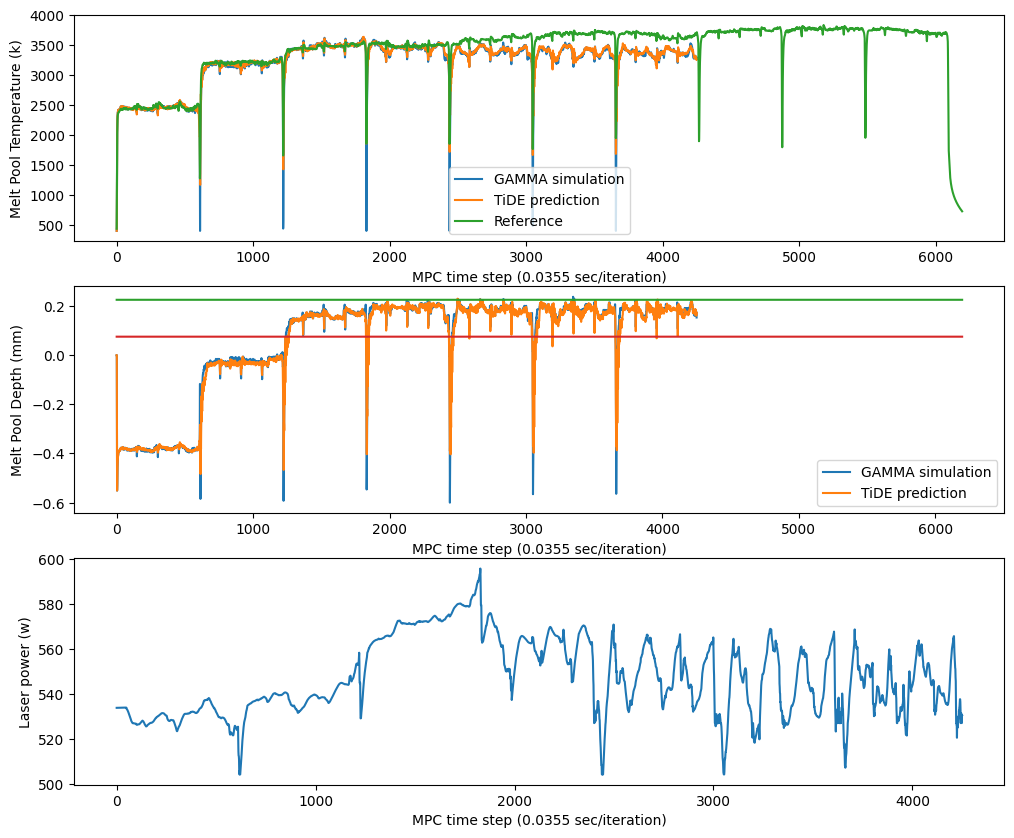

 68%|██████▊   | 4201/6196 [2:57:31<17:58,  1.85it/s]

[Step 4251] Warm-start: 2 iterations


 68%|██████▊   | 4202/6196 [2:57:31<15:44,  2.11it/s]

[Step 4252] Warm-start: 1 iterations
[Step 4252] Cold-start fallback: 1 iterations


 68%|██████▊   | 4203/6196 [2:57:32<14:12,  2.34it/s]

...

[Step 4848] Warm-start: 1 iterations
[Step 4848] Cold-start fallback: 2 iterations


 77%|███████▋  | 4799/6196 [3:02:06<10:43,  2.17it/s]

[Step 4849] Warm-start: 1 iterations
[Step 4849] Cold-start fallback: 2 iterations


 77%|███████▋  | 4800/6196 [3:02:06<11:14,  2.07it/s]

[Step 4850] Warm-start: 1 iterations
[Step 4850] Cold-start fallback: 1 iterations


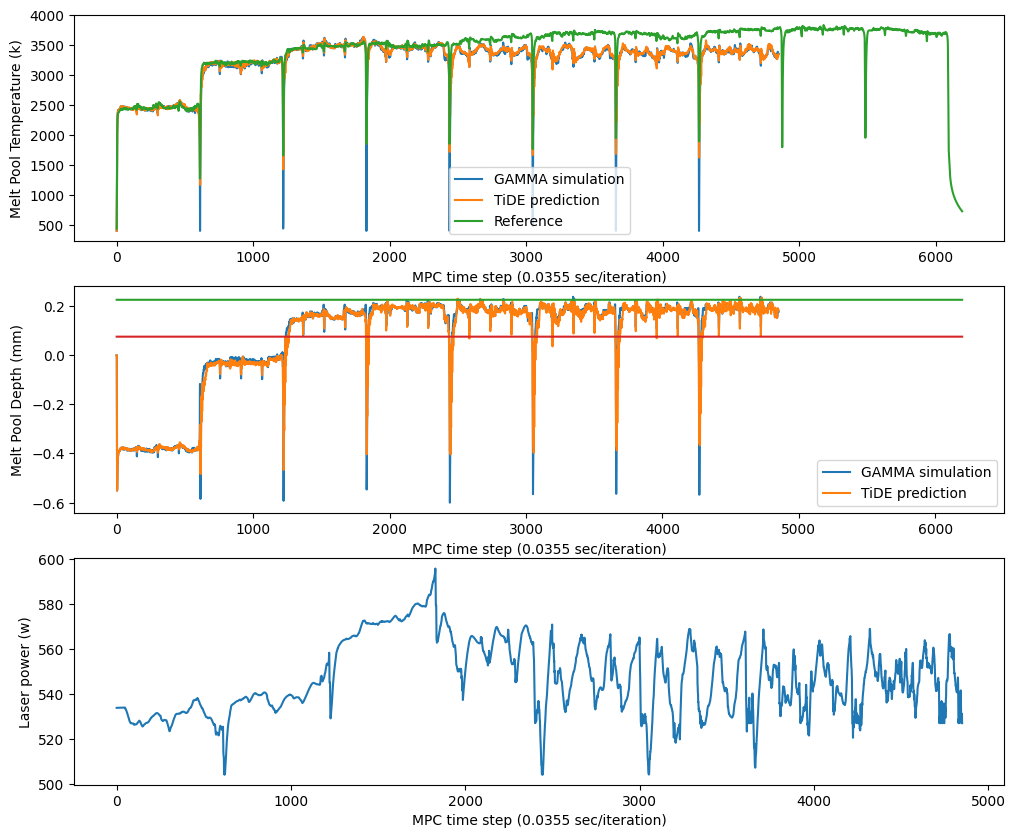

 77%|███████▋  | 4801/6196 [3:02:07<13:03,  1.78it/s]

[Step 4851] Warm-start: 1 iterations
[Step 4851] Cold-start fallback: 1 iterations


 78%|███████▊  | 4803/6196 [3:02:08<14:18,  1.62it/s]

[Step 4852] Warm-start: 2 iterations
[Step 4853] Warm-start: 1 iterations
[Step 4853] Cold-start fallback: 1 iterations


 78%|███████▊  | 4804/6196 [3:02:09<13:56,  1.66it/s]

...

[Step 5447] Warm-start: 4 iterations


 87%|████████▋ | 5399/6196 [3:06:36<05:35,  2.38it/s]

[Step 5448] Warm-start: 6 iterations
[Step 5449] Warm-start: 4 iterations


 87%|████████▋ | 5400/6196 [3:06:36<05:21,  2.47it/s]

[Step 5450] Warm-start: 2 iterations


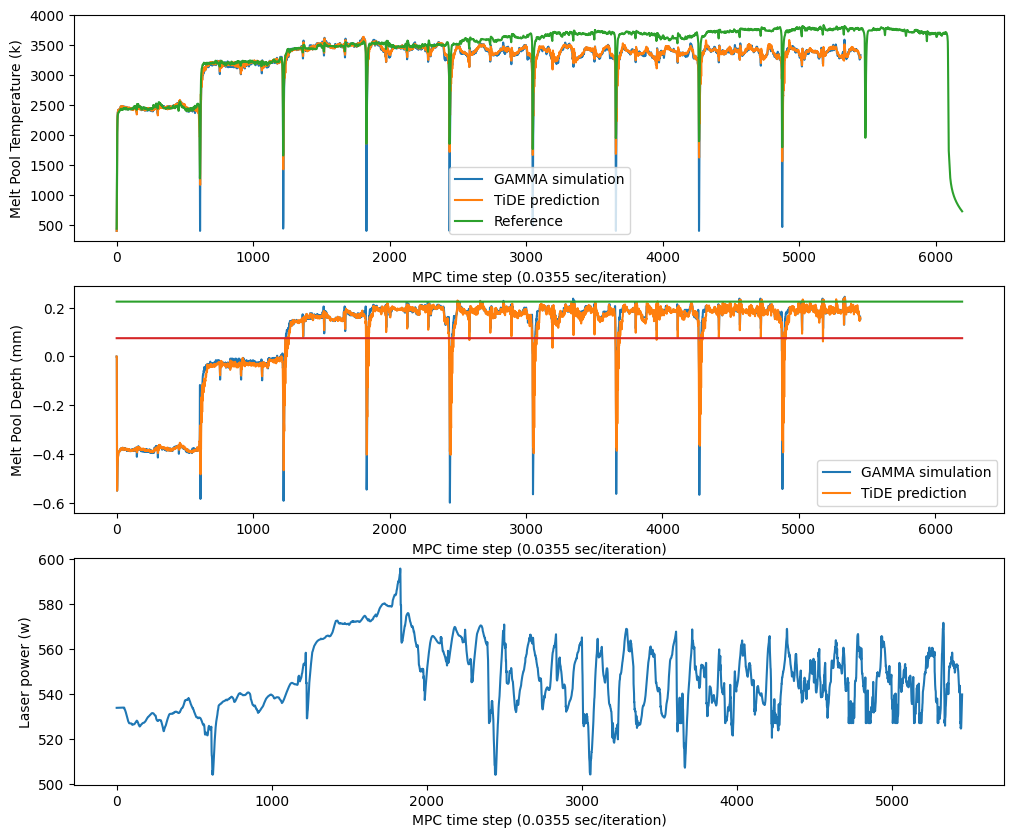

 87%|████████▋ | 5402/6196 [3:06:37<06:30,  2.03it/s]

[Step 5451] Warm-start: 19 iterations


 87%|████████▋ | 5403/6196 [3:06:38<05:50,  2.26it/s]

[Step 5452] Warm-start: 3 iterations


 87%|████████▋ | 5404/6196 [3:06:38<05:58,  2.21it/s]

...

[Step 6048] Warm-start: 2 iterations


 97%|█████████▋| 5999/6196 [3:10:27<01:25,  2.31it/s]

[Step 6049] Warm-start: 2 iterations


 97%|█████████▋| 6000/6196 [3:10:28<01:15,  2.60it/s]

[Step 6050] Warm-start: 2 iterations


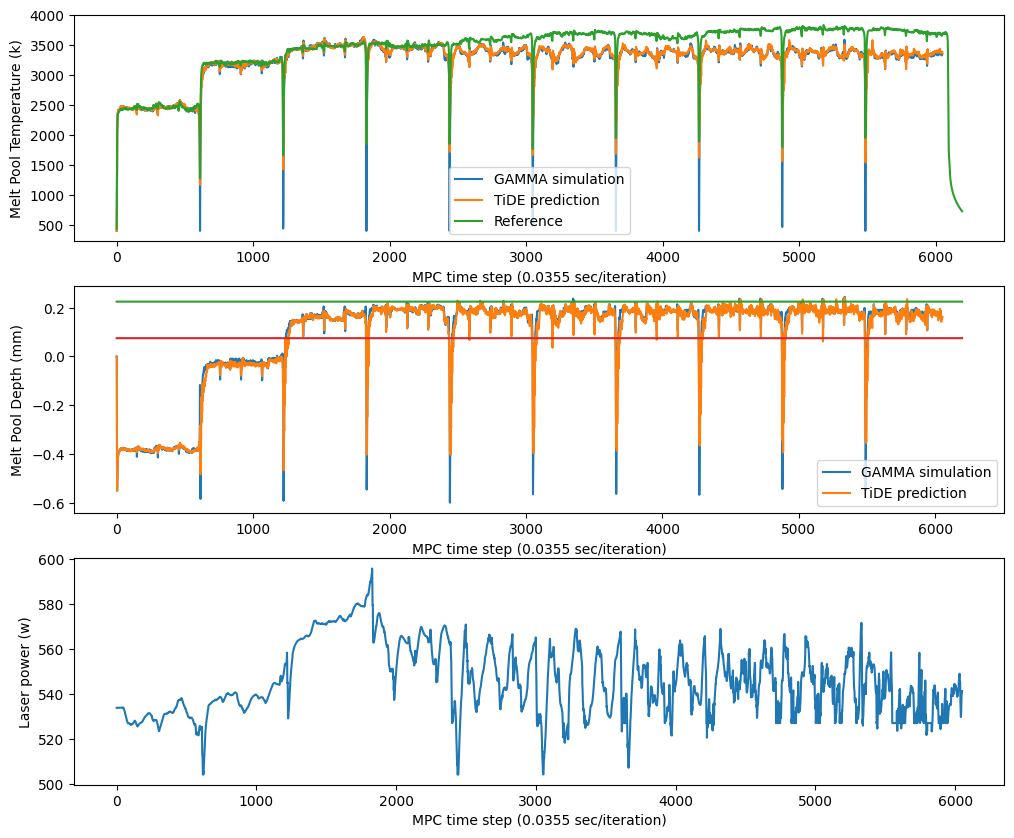

 97%|█████████▋| 6001/6196 [3:10:28<01:25,  2.29it/s]

[Step 6051] Warm-start: 2 iterations


 97%|█████████▋| 6002/6196 [3:10:29<01:18,  2.49it/s]

[Step 6052] Warm-start: 2 iterations


 97%|█████████▋| 6003/6196 [3:10:29<01:23,  2.31it/s]

...

100%|█████████▉| 6194/6196 [3:12:17<00:01,  1.86it/s]

[Step 6244] Warm-start: 1 iterations
[Step 6244] Cold-start fallback: 1 iterations


100%|█████████▉| 6195/6196 [3:12:18<00:00,  1.83it/s]

[Step 6245] Warm-start: 1 iterations
[Step 6245] Cold-start fallback: 1 iterations


100%|██████████| 6196/6196 [3:12:18<00:00,  1.86s/it]


In [24]:
MPC_GAMMA = GAMMA_MPC(GAMMA_class, TiDE, RMPC_obj_w_constraint, mp_temp_ref, window, P, fix_covariates, init_avg, laser_power_past, LossParam, global_state)
#N_step = 6021 #6196
#N_step = 6196

N_step = 6196 - init_runs + 50

#RUN = "MPC"
RUN = "MPC"

if RUN == "MPC":
    import csv
    with open("iteration_log.csv", mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["timestep", "iterations", "type"])
        
    for i in tqdm(range(N_step)):
        MPC_GAMMA.MPC_run_one_step_pytorch()
        if i % 600 == 0:
            plot_fig(MPC_GAMMA, N_step)

elif RUN == "PID":
    for i in tqdm(range(N_step)):
        MPC_GAMMA.PID_run_one_step()
        
else:
    print(f"No control method available")

In [25]:
MPC_GAMMA.NN_pred_save_temp_ub[:,49]

tensor([   0.0000, 2610.3274, 2645.9292,  ...,       nan,       nan,
              nan], grad_fn=<SelectBackward0>)

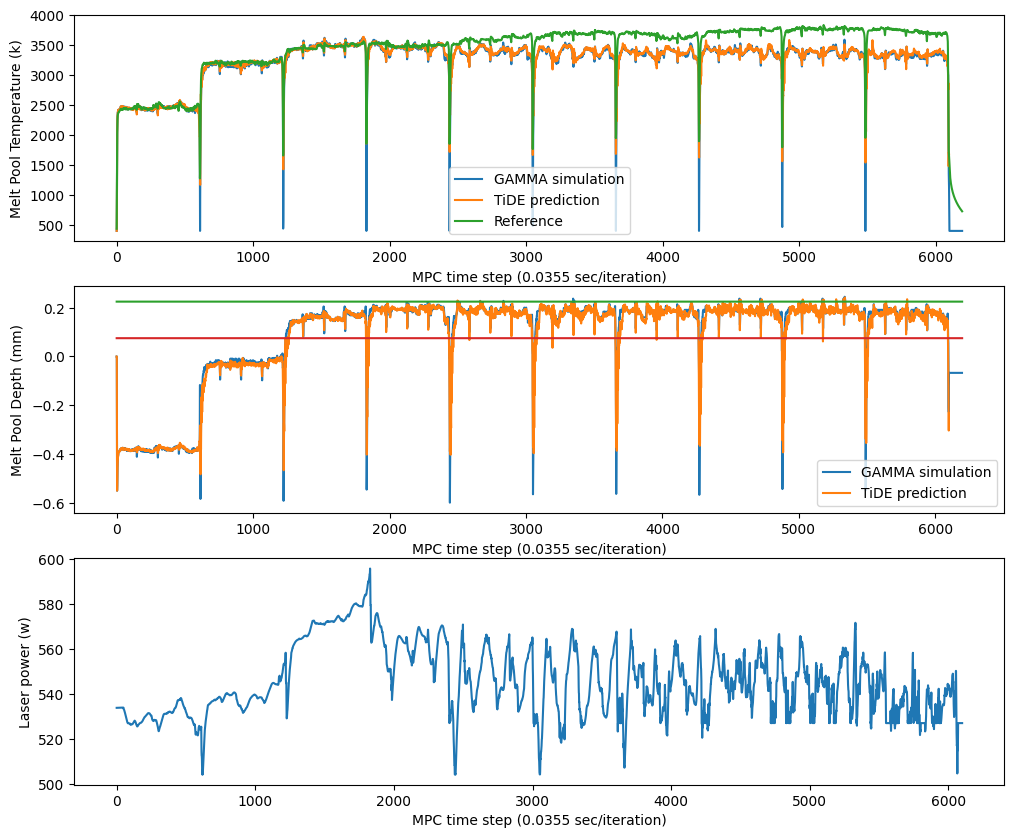

In [26]:
N_step = 6196
plt.figure(figsize=[12,10])
plt.subplot(3,1,1)
plt.plot(MPC_GAMMA.x_past_save[:N_step,0], label = "GAMMA simulation")
plt.plot(MPC_GAMMA.NN_pred_save.detach().numpy()[:N_step,0], label="TiDE prediction")
plt.plot(MPC_GAMMA.ref[:N_step], label="Reference")
plt.legend()


plt.xlabel("MPC time step (0.0355 sec/iteration)")
plt.ylabel("Melt Pool Temperature (k)")

plt.subplot(3,1,2)
plt.plot(MPC_GAMMA.x_past_save[:N_step,1], label = "GAMMA simulation")
plt.plot(MPC_GAMMA.NN_pred_save.detach().numpy()[:N_step,1], label="TiDE prediction")
plt.plot(np.linspace(0,N_step,N_step),0.225*np.ones(N_step))
plt.plot(np.linspace(0,N_step,N_step),0.075*np.ones(N_step))
plt.xlabel("MPC time step (0.0355 sec/iteration)")
plt.ylabel("Melt Pool Depth (mm)")
plt.legend()

plt.subplot(3,1,3)
plt.plot(MPC_GAMMA.u_past_save[:N_step])
plt.ylabel("Laser power (w)")
plt.xlabel("MPC time step (0.0355 sec/iteration)")
plt.show()


np.float64(1.6439428158619083)

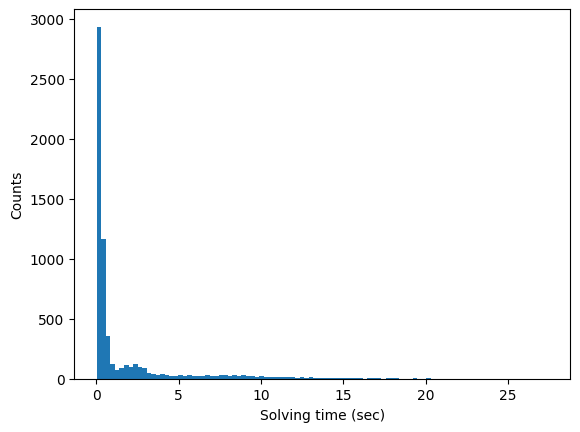

In [27]:
time = np.array(MPC_GAMMA.save_time) * -1
plt.hist(time,100)
plt.xlabel("Solving time (sec)")
plt.ylabel("Counts")
np.mean(time)

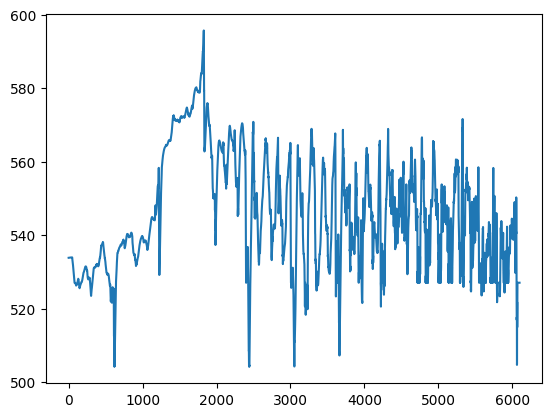

In [28]:
plt.plot(MPC_GAMMA.u_past_save)

In [29]:
import pandas as pd
# Assuming the three variables are numpy arrays or lists
gamma_result_temp = MPC_GAMMA.x_past_save[:N_step,0].squeeze()
gamma_result_depth = MPC_GAMMA.x_past_save[:N_step,1].squeeze()
ref = MPC_GAMMA.ref[:N_step]
TiDE_pred_temp = MPC_GAMMA.NN_pred_save.detach().numpy()[:N_step,0]
TiDE_pred_depth = MPC_GAMMA.NN_pred_save.detach().numpy()[:N_step,1]
LP = MPC_GAMMA.u_past_save[:N_step].squeeze()

# Create a dictionary with the data
data = {
    'gamma_result_temp': gamma_result_temp,
    'gamma_result_depth': gamma_result_depth,
    'ref': ref,
    'TiDE_pred_temp': TiDE_pred_temp,
    'TiDE_pred_depth': TiDE_pred_depth,
    'Time': np.array(MPC_GAMMA.save_time) * -1,
    'LP': LP
}

# data = {
#     'gamma_result': gamma_result,
#     'ref': ref,
#     'LP': LP
# }

# Create a DataFrame
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('profile_1_RMPC_w_depth_control.csv', index=False)

In [30]:
# save step-by-step prediction
depth_lb = pd.DataFrame(MPC_GAMMA.NN_pred_save_depth_lb.detach().numpy())
depth_lb.to_csv("save_step_depth_lb_RMPC.csv", index=False)

depth_ub = pd.DataFrame(MPC_GAMMA.NN_pred_save_depth_ub.detach().numpy())
depth_ub.to_csv("save_step_depth_ub_RMPC.csv", index=False)

depth_med = pd.DataFrame(MPC_GAMMA.NN_pred_save_depth_med.detach().numpy())
depth_med.to_csv("save_step_depth_med_RMPC.csv", index=False)

temp_lb = pd.DataFrame(MPC_GAMMA.NN_pred_save_temp_lb.detach().numpy())
temp_lb.to_csv("save_step_temp_lb_RMPC.csv", index=False)

temp_ub = pd.DataFrame(MPC_GAMMA.NN_pred_save_temp_ub.detach().numpy())
temp_ub.to_csv("save_step_temp_ub_RMPC.csv", index=False)

temp_med = pd.DataFrame(MPC_GAMMA.NN_pred_save_temp_med.detach().numpy())
temp_med.to_csv("save_step_temp_med_RMPC.csv", index=False)


#### Pytorch minimize w/o input bounds


In [31]:
#  === Initial Conditions: Values at time = k ===============
k = 50


# temporary ref 
mp_temp_ref_part = mp_temp_ref[k:k+P] + torch.tensor(np.linspace(0,30,50),dtype=torch.float32)

mp_temp_ref_part_s = TiDE.scaler_y(mp_temp_ref_part)

# past melt pool temperature
mp_temp_past_part = mp_temp_ref[k-window:k]
mp_temp_past_part_s = TiDE.scaler_y(mp_temp_past_part).transpose(1,0)

# assume the past history is the same as the first term at the first step
fix_cov_past = fix_covariates[k-window:k,:]
fix_cov_past_s = TiDE.scaler_x(fix_cov_past,dim_id=[0,1,2])

# fix future covariate
fix_cov_future = fix_covariates[k:k+P,:]
fix_cov_future_s = TiDE.scaler_x(fix_cov_future,dim_id=[0,1,2])

# past laser power: take the given ones first
past_laser_power = laser_power_ref[k-window:k]
past_laser_power_s = TiDE.scaler_x(past_laser_power,dim_id=3)
future_laser_power = laser_power_ref[k:k+P]
future_laser_power_s = TiDE.scaler_x(future_laser_power,dim_id=3)

# designed laser power
u_hat = torch.zeros((P,1),dtype=torch.float32)
solution = pytorch_minimize(lambda u:RMPC_obj_wo_constraint(u,fix_cov_future_s,past_laser_power_s,fix_cov_past_s, mp_temp_past_part_s,mp_temp_ref_part_s,P,TiDE),torch.zeros((P,1)),method="l-bfgs")

mp_hat_opt_s = TiDE.forward(solution.x, fix_cov_future_s, past_laser_power_s, fix_cov_past_s, mp_temp_past_part_s) # predicted MP temp
mp_hat_opt = TiDE.inv_scaler_y(mp_hat_opt_s)
mp_real_s = TiDE.forward(future_laser_power_s, fix_cov_future_s, past_laser_power_s, fix_cov_past_s, mp_temp_past_part_s) # predicted MP temp
mp_real = TiDE.inv_scaler_y(mp_real_s)
mp_hat_ini_guess_s = TiDE.forward(torch.ones((P,1)), fix_cov_future_s, past_laser_power_s, fix_cov_past_s, mp_temp_past_part_s)
mp_hat_ini_guess = TiDE.inv_scaler_y(mp_hat_ini_guess_s)

plt.plot(mp_hat_opt.squeeze().detach().numpy(), label="prediction via MPC")
plt.plot(mp_temp_ref_part.numpy(), label="ref")
plt.plot(mp_real.detach().numpy().T, label='prediction with future LP')
# plt.plot(mp_hat_ini_guess.detach().numpy().T, label="prediction with initial guess")
plt.legend()
#plt.ylim([2200,2400])
plt.show()

plt.figure()
plt.plot(TiDE.inv_scaler_x(solution.x.detach(),dim_id=3),label='opt')
plt.plot(TiDE.inv_scaler_x(future_laser_power_s,dim_id=3),label='true')
plt.legend()



RuntimeError: The size of tensor a (50) must match the size of tensor b (2) at non-singleton dimension 1